In [1]:
# 1. GLOBAL LIBRARIES
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# Keras & TensorFlow (Keras 3 Compliant)
import tensorflow as tf
from tensorflow.keras.layers import (
    Layer, Input, Conv1D, BatchNormalization, Bidirectional, 
    GRU, Dense, Dropout, GlobalAveragePooling1D, Multiply, Softmax
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Metrics & Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay

# Your Custom Feature Module (Must be in the same directory)
from feature_extractor import process_audio_file

I0000 00:00:1775193962.710290    3802 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775193962.717300    3802 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775193963.454490    3802 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775193967.070522    3802 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [ ]:
# 2. GLOBAL CONSTANTS & PATHS
SEQ_LEN = 300
FEATURE_DIM = 710

# Cache Directory for Pre-computed Tensors
CACHE_DIR = Path('asvspoof_train_cache')
CACHE_DIR.mkdir(exist_ok=True)
INDEX_PATH = CACHE_DIR / 'dataset_index.json'

# ASVspoof 2019 LA Paths (TRAIN SET)
TRAIN_PROTOCOL = Path("la/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt")
TRAIN_AUDIO_DIR = Path("la/ASVspoof2019_LA_train/flac")

# ASVspoof 2019 LA Paths (DEV SET - FOR EVALUATION)
DEV_PROTOCOL = Path("la/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt")
DEV_AUDIO_DIR = Path("la/ASVspoof2019_LA_dev/flac")

# Model Save Path
MODEL_PATH = "MOdel2.o.keras"

In [3]:
# 3. CUSTOM MAX-FEATURE-MAP LAYER
class MaxFeatureMap1D(Layer):
    """
    Max-Feature-Map (MFM) activation for 1D sequences.
    Splits the channel dimension in half and takes the element-wise maximum.
    Filters out background noise, retaining only highly discriminative artifacts.
    """
    def __init__(self, **kwargs):
        super(MaxFeatureMap1D, self).__init__(**kwargs)

    def call(self, inputs):
        channels = tf.shape(inputs)[-1]
        half_channels = channels // 2
        x1 = inputs[:, :, :half_channels]
        x2 = inputs[:, :, half_channels:]
        return tf.maximum(x1, x2)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1], input_shape[2] // 2)

# TRAINING PHASE BLOCKS 

In [4]:
# 4. DATA EXTRACTION & CACHING (ASVSPOOF TRAIN SET)
def cache_asvspoof_train_data():
    if INDEX_PATH.exists():
        print("Loading pre-computed dataset index from disk...")
        with open(INDEX_PATH, 'r') as f:
            return json.load(f)
            
    print("Initiating Feature Extraction on ASVspoof Training Set...")
    dataset_index = []
    
    with open(TRAIN_PROTOCOL, 'r') as f:
        lines = f.readlines()
        
    for line in tqdm(lines, desc="Processing Audio Files"):
        parts = line.strip().split()
        if len(parts) >= 5:
            file_id = parts[1]
            label = 0.0 if parts[4] == 'bonafide' else 1.0
            flac_path = TRAIN_AUDIO_DIR / f"{file_id}.flac"
            
            if flac_path.exists():
                try:
                    # 1. Extract Full Features
                    features = process_audio_file(str(flac_path))
                    
                    # 2. Strict Truncation BEFORE saving (Saves ~60% Storage)
                    t_frames = features.shape[0]
                    if t_frames > SEQ_LEN:
                        features = features[:SEQ_LEN, :]
                        
                    # 3. Precision Compression (Saves 75% Storage)
                    features = features.astype(np.float16)
                    
                    # 4. Write to Disk
                    save_path = CACHE_DIR / f"{file_id}.npy"
                    np.save(save_path, features)
                    dataset_index.append({'path': str(save_path), 'label': label})
                except Exception as e:
                    pass # Skip corrupted files
                    
    with open(INDEX_PATH, 'w') as f:
        json.dump(dataset_index, f)
        
    return dataset_index

dataset_index = cache_asvspoof_train_data()
print(f"Total training profiles cached: {len(dataset_index)}")

Initiating Feature Extraction on ASVspoof Training Set...


Processing Audio Files:   0%|          | 0/25380 [00:00<?, ?it/s]/home/tech_adnan/noise_project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tech_adnan/noise_project/NOISE_CANCELLATION/Deepfake_project/feature_extractor.py:195: UserWarning: With fmin=100.000, sr=16000 and frame_length=320, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=100.000 or frame_length=321.
  f0 = librosa.yin(
Processing Audio Files: 100%|██████████| 25380/25380 [15:58<00:00, 26.49it/s] 


Total training profiles cached: 25380


In [5]:
# 5. INTEGRITY VERIFICATION
def verify_cache_integrity(index_list, sample_ratio=0.05):
    sample_size = max(1, int(len(index_list) * sample_ratio))
    sampled_items = random.sample(index_list, sample_size)
    print(f"--- Checking Tensor Integrity ({sample_size} files) ---")
    
    errors = 0
    for item in sampled_items:
        try:
            tensor = np.load(item['path'])
            if len(tensor.shape) != 2 or tensor.shape[1] != FEATURE_DIM: errors += 1
            if np.isnan(tensor).any() or np.isinf(tensor).any(): errors += 1
        except: errors += 1
            
    if errors == 0: print("SUCCESS: Tensors are mathematically stable.")
    else: print(f"WARNING: Found {errors} corrupted tensors.")

verify_cache_integrity(dataset_index)

--- Checking Tensor Integrity (1269 files) ---
SUCCESS: Tensors are mathematically stable.


In [6]:
# 6. GENERATOR & ARCHITECTURE
class AudioForensicGenerator(tf.keras.utils.Sequence):
    def __init__(self, data_index, batch_size=32):
        self.data_index, self.batch_size = data_index, batch_size
        self.indices = np.arange(len(self.data_index))
        np.random.shuffle(self.indices)
        
    def __len__(self):
        return int(np.ceil(len(self.data_index) / self.batch_size))
        
    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        X_batch = np.zeros((len(batch_indices), SEQ_LEN, FEATURE_DIM), dtype=np.float32)
        Y_batch = np.zeros((len(batch_indices), 1), dtype=np.float32)
        
        for i, idx in enumerate(batch_indices):
            item = self.data_index[idx]
            features = np.load(item['path'])
            t_frames = features.shape[0]
            if t_frames >= SEQ_LEN: X_batch[i] = features[:SEQ_LEN, :]
            else: X_batch[i, :t_frames, :] = features
            Y_batch[i, 0] = item['label']
            
        return X_batch, Y_batch
        
    def on_epoch_end(self):
        np.random.shuffle(self.indices)

def build_lcnn_bigru_discriminator():
    inputs = Input(shape=(SEQ_LEN, FEATURE_DIM))

    # LCNN Blocks
    x = Dropout(0.3)(MaxFeatureMap1D()(BatchNormalization()(Conv1D(256, 3, padding='same')(inputs))))
    x = Dropout(0.3)(MaxFeatureMap1D()(BatchNormalization()(Conv1D(128, 3, padding='same')(x))))

    # Temporal BiGRU Block
    x = Bidirectional(GRU(64, return_sequences=True))(x)
    
    # REPAIRED: Attention Mechanism (Softmax across Time Axis)
    attention_scores = Dense(1)(x) 
    attention_weights = Softmax(axis=1)(attention_scores) 
    context_vector = Multiply()([x, attention_weights])
    
    x = GlobalAveragePooling1D()(context_vector)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

# Instantiate the model to check the architecture
model_preview = build_lcnn_bigru_discriminator()

# Print the model summary table
print("\n--- Model Architecture Overview ---")
model_preview.summary()


--- Model Architecture Overview ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 710)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 300, 256)  │    545,536 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 300, 256)  │      1,024 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_feature_map1d   │ (None, 300, 128)  │          0 │ batch_normalizat… │
│ (MaxFeatureMap1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 300, 128)  │          0 │ max_feature_map1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 300, 128)  │     49,280 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_feature_map1d_1 │ (None, 300, 64)   │          0 │ batch_normalizat… │
│ (MaxFeatureMap1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 300, 64)   │          0 │ max_feature_map1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 300, 128)  │     49,920 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 300, 1)    │        129 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 300, 1)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 300, 128)  │          0 │ bidirectional[0]… │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      4,128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 650,562 (2.48 MB)

 Trainable params: 649,794 (2.48 MB)

 Non-trainable params: 768 (3.00 KB)

In [9]:
# 7. EXECUTE TRAINING
from tensorflow.keras.callbacks import CSVLogger

train_idx, val_idx = train_test_split(dataset_index, test_size=0.2, random_state=42, stratify=[d['label'] for d in dataset_index])

train_gen = AudioForensicGenerator(train_idx)
val_gen = AudioForensicGenerator(val_idx)
model = build_lcnn_bigru_discriminator()

# Define the CSV Logger to write metrics after every epoch
csv_logger = CSVLogger('deepcheck_training_history.csv', append=False)

callbacks = [
    ModelCheckpoint(MODEL_PATH, monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    csv_logger  # Injecting the logger into the callbacks array
]

print("Initiating LCNN-BiGRU Training Matrix...")
history = model.fit(train_gen, validation_data=val_gen, epochs=30, callbacks=callbacks)

Initiating LCNN-BiGRU Training Matrix...


/home/tech_adnan/noise_project/.venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1775152044.770563  209110 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


635/635 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8999 - auc: 0.5075 - loss: 0.6404
Epoch 1: val_auc improved from None to 0.49956, saving model to deepcheck_asvspoof_model.keras
635/635 ━━━━━━━━━━━━━━━━━━━━ 279s 433ms/step - accuracy: 0.8983 - auc: 0.4908 - loss: 0.5922 - val_accuracy: 0.8983 - val_auc: 0.4996 - val_loss: 0.4975 - learning_rate: 1.0000e-04
Epoch 2/30
635/635 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.8993 - auc: 0.4951 - loss: 0.4624
Epoch 2: val_auc improved from 0.49956 to 0.49978, saving model to deepcheck_asvspoof_model.keras
635/635 ━━━━━━━━━━━━━━━━━━━━ 282s 444ms/step - accuracy: 0.8983 - auc: 0.4944 - loss: 0.4335 - val_accuracy: 0.8983 - val_auc: 0.4998 - val_loss: 0.3793 - learning_rate: 1.0000e-04
Epoch 3/30
635/635 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8989 - auc: 0.5001 - loss: 0.3695
Epoch 3: val_auc improved from 0.49978 to 0.60146, saving model to deepcheck_asvspoof_model.keras
635/635 ━━━━━━━━━━━━━━━━━━━━ 258s 405ms/step - accur

KeyboardInterrupt: 

# EVALUATION PHASE BLOCKS

--- Initiating ASVspoof 2019 Dev Evaluation ---


Extracting & Predicting:   0%|          | 0/10000 [00:00<?, ?it/s]/home/tech_adnan/noise_project/NOISE_CANCELLATION/Deepfake_project/feature_extractor.py:195: UserWarning: With fmin=100.000, sr=16000 and frame_length=320, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=100.000 or frame_length=321.
  f0 = librosa.yin(
Extracting & Predicting: 100%|██████████| 10000/10000 [38:57<00:00,  4.28it/s] 



--- Results ---
F1 Score (Threshold 0.5): 0.9912
Equal Error Rate (EER):   3.81%
Optimal EER Threshold:    0.9836


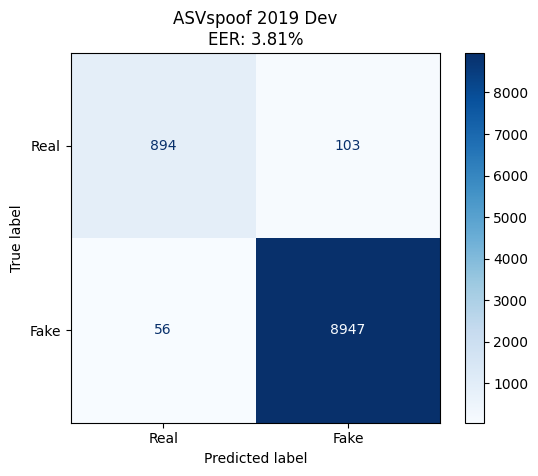

In [11]:
# 8. BLIND EVALUATION (ASVSPOOF DEV SET)
def evaluate_on_asvspoof(max_files=None):
    print("--- Initiating ASVspoof 2019 Dev Evaluation ---")
    try:
        model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'MaxFeatureMap1D': MaxFeatureMap1D})
    except Exception as e:
        print(f"Failed to load model: {e}"); return
        
    with open(DEV_PROTOCOL, 'r') as f: lines = f.readlines()
    if max_files: 
        np.random.seed(42); np.random.shuffle(lines); lines = lines[:max_files]
        
    y_true, audio_paths = [], []
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            flac_path = DEV_AUDIO_DIR / f"{parts[1]}.flac"
            if flac_path.exists():
                audio_paths.append(flac_path)
                y_true.append(0.0 if parts[4] == 'bonafide' else 1.0)

    y_pred_probs, y_true_clean = [], []
    for i, path in enumerate(tqdm(audio_paths, desc="Extracting & Predicting")):
        try:
            features = process_audio_file(str(path))
            X_input = np.zeros((1, SEQ_LEN, FEATURE_DIM), dtype=np.float32)
            t_frames = features.shape[0]
            if t_frames >= SEQ_LEN: X_input[0] = features[:SEQ_LEN, :]
            else: X_input[0, :t_frames, :] = features
                
            y_pred_probs.append(model.predict(X_input, verbose=0)[0][0])
            y_true_clean.append(y_true[i])
        except: pass

    y_true_clean, y_pred_probs = np.array(y_true_clean), np.array(y_pred_probs)
    y_pred_binary = (y_pred_probs > 0.5).astype(float)

    # Metrics
    fpr, tpr, thresholds = roc_curve(y_true_clean, y_pred_probs)
    eer_index = np.nanargmin(np.absolute((1 - tpr) - fpr))
    eer = fpr[eer_index]
    
    print("\n--- Results ---")
    print(f"F1 Score (Threshold 0.5): {f1_score(y_true_clean, y_pred_binary):.4f}")
    print(f"Equal Error Rate (EER):   {eer*100:.2f}%")
    print(f"Optimal EER Threshold:    {thresholds[eer_index]:.4f}")

    disp = ConfusionMatrixDisplay(confusion_matrix(y_true_clean, y_pred_binary), display_labels=['Real', 'Fake'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"ASVspoof 2019 Dev\nEER: {eer*100:.2f}%")
    plt.show()

# Set max_files=1000 for a quick test, or None to evaluate all 24,000 files.
evaluate_on_asvspoof(max_files=10000)

--- Initiating Balanced ASVspoof 2019 Dev Evaluation (1000 per class) ---


E0000 00:00:1775159045.719170  462603 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Sampled exactly 1000 Real and 1000 Fake files for a perfectly balanced test.


Extracting & Predicting:   0%|          | 0/2000 [00:00<?, ?it/s]/home/tech_adnan/noise_project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tech_adnan/noise_project/NOISE_CANCELLATION/Deepfake_project/feature_extractor.py:195: UserWarning: With fmin=100.000, sr=16000 and frame_length=320, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=100.000 or frame_length=321.
  f0 = librosa.yin(
Extracting & Predicting: 100%|██████████| 2000/2000 [08:00<00:00,  4.16it/s]


--- Balanced Results ---
F1 Score (Threshold 0.5): 0.9492
Equal Error Rate (EER):   3.90%
Optimal EER Threshold:    0.9852


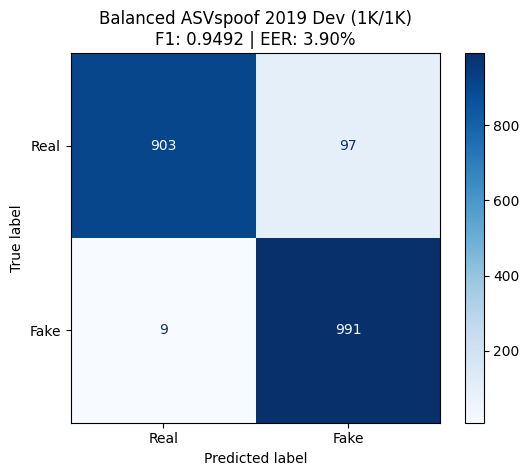

In [5]:
# 8. BALANCED BLIND EVALUATION (ASVSPOOF DEV SET)
import random

def evaluate_balanced_asvspoof(samples_per_class=1000):
    print(f"--- Initiating Balanced ASVspoof 2019 Dev Evaluation ({samples_per_class} per class) ---")
    
    # 1. Load Model
    try:
        model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'MaxFeatureMap1D': MaxFeatureMap1D})
    except Exception as e:
        print(f"Failed to load model: {e}"); return
        
    # 2. Parse Protocol and Separate Classes
    with open(DEV_PROTOCOL, 'r') as f: 
        lines = f.readlines()
        
    reals = []
    fakes = []
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            if parts[4] == 'bonafide':
                reals.append(line)
            else:
                fakes.append(line)
                
    # 3. Shuffle and Sample Exactly 50/50
    random.seed(42)
    random.shuffle(reals)
    random.shuffle(fakes)
    
    # Prevent out-of-bounds errors if requesting more files than exist
    n_reals = min(samples_per_class, len(reals))
    n_fakes = min(samples_per_class, len(fakes))
    
    balanced_lines = reals[:n_reals] + fakes[:n_fakes]
    random.shuffle(balanced_lines) # Mix them up for the inference loop
    
    print(f"Sampled exactly {n_reals} Real and {n_fakes} Fake files for a perfectly balanced test.")
        
    # 4. Map Paths
    y_true, audio_paths = [], []
    for line in balanced_lines:
        parts = line.strip().split()
        flac_path = DEV_AUDIO_DIR / f"{parts[1]}.flac"
        if flac_path.exists():
            audio_paths.append(flac_path)
            y_true.append(0.0 if parts[4] == 'bonafide' else 1.0)

    # 5. Extraction & Inference Loop
    y_pred_probs, y_true_clean = [], []
    for i, path in enumerate(tqdm(audio_paths, desc="Extracting & Predicting")):
        try:
            features = process_audio_file(str(path))
            X_input = np.zeros((1, SEQ_LEN, FEATURE_DIM), dtype=np.float32)
            t_frames = features.shape[0]
            
            if t_frames >= SEQ_LEN: X_input[0] = features[:SEQ_LEN, :]
            else: X_input[0, :t_frames, :] = features
                
            y_pred_probs.append(model.predict(X_input, verbose=0)[0][0])
            y_true_clean.append(y_true[i])
        except: pass

    y_true_clean = np.array(y_true_clean)
    y_pred_probs = np.array(y_pred_probs)
    
    # Base threshold at 0.5
    y_pred_binary = (y_pred_probs > 0.5).astype(float)

    # 6. Metrics Calculation
    fpr, tpr, thresholds = roc_curve(y_true_clean, y_pred_probs)
    eer_index = np.nanargmin(np.absolute((1 - tpr) - fpr))
    eer = fpr[eer_index]
    
    f1 = f1_score(y_true_clean, y_pred_binary)
    
    print("\n--- Balanced Results ---")
    print(f"F1 Score (Threshold 0.5): {f1:.4f}")
    print(f"Equal Error Rate (EER):   {eer*100:.2f}%")
    print(f"Optimal EER Threshold:    {thresholds[eer_index]:.4f}")

    # 7. Confusion Matrix Plot
    cm = confusion_matrix(y_true_clean, y_pred_binary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Balanced ASVspoof 2019 Dev (1K/1K)\nF1: {f1:.4f} | EER: {eer*100:.2f}%")
    plt.show()

# Execute the perfectly balanced evaluation
evaluate_balanced_asvspoof(samples_per_class=1000)

--- Initiating Balanced ASVspoof 2019 EVAL Evaluation (1000 per class) ---
Sampled exactly 1000 Real and 1000 Fake files from the Eval set.


Extracting & Predicting:   0%|          | 0/2000 [00:00<?, ?it/s]/home/tech_adnan/noise_project/NOISE_CANCELLATION/Deepfake_project/feature_extractor.py:195: UserWarning: With fmin=100.000, sr=16000 and frame_length=320, less than two periods of fmin fit into the frame, which can cause inaccurate pitch detection. Consider increasing to fmin=100.000 or frame_length=321.
  f0 = librosa.yin(
Extracting & Predicting: 100%|██████████| 2000/2000 [05:42<00:00,  5.84it/s]



--- Balanced Eval Results (Unknown Attacks) ---
F1 Score (Threshold 0.5): 0.8807
Equal Error Rate (EER):   11.80%
Optimal EER Threshold:    0.1742


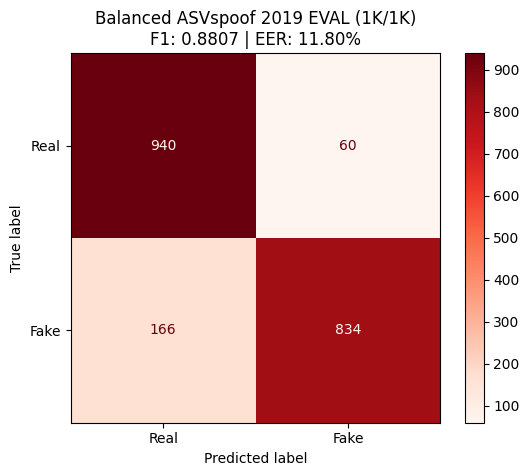

In [7]:
# 10. BALANCED BLIND EVALUATION (ASVSPOOF EVAL SET - UNKNOWN ATTACKS)
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import tensorflow as tf
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay

# Define Eval Paths locally
EVAL_PROTOCOL = Path("la/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt")
EVAL_AUDIO_DIR = Path("la/ASVspoof2019_LA_eval/flac")

def evaluate_balanced_asvspoof_eval(samples_per_class=1000):
    print(f"--- Initiating Balanced ASVspoof 2019 EVAL Evaluation ({samples_per_class} per class) ---")
    print("Warning: Model is now facing Unknown Attacks...")
    
    # 1. Load Model
    try:
        model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'MaxFeatureMap1D': MaxFeatureMap1D})
    except Exception as e:
        print(f"Failed to load model: {e}")
        return
        
    # 2. Parse Protocol and Separate Classes
    if not EVAL_PROTOCOL.exists():
        print(f"Cannot find protocol file at: {EVAL_PROTOCOL}")
        return

    with open(EVAL_PROTOCOL, 'r') as f: 
        lines = f.readlines()
        
    reals = []
    fakes = []
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            if parts[4] == 'bonafide':
                reals.append(line)
            else:
                fakes.append(line)
                
    # 3. Shuffle and Sample Exactly 50/50
    random.seed(42)
    random.shuffle(reals)
    random.shuffle(fakes)
    
    n_reals = min(samples_per_class, len(reals))
    n_fakes = min(samples_per_class, len(fakes))
    
    balanced_lines = reals[:n_reals] + fakes[:n_fakes]
    random.shuffle(balanced_lines) 
    
    print(f"Sampled exactly {n_reals} Real and {n_fakes} Fake files from the Eval set.")
        
    # 4. Map Paths
    y_true, audio_paths = [], []
    for line in balanced_lines:
        parts = line.strip().split()
        flac_path = EVAL_AUDIO_DIR / f"{parts[1]}.flac"
        if flac_path.exists():
            audio_paths.append(flac_path)
            y_true.append(0.0 if parts[4] == 'bonafide' else 1.0)
        else:
            print(f"Missing audio file: {flac_path}")

    # 5. Extraction & Inference Loop
    y_pred_probs, y_true_clean = [], []
    for i, path in enumerate(tqdm(audio_paths, desc="Extracting & Predicting")):
        try:
            features = process_audio_file(str(path))
            X_input = np.zeros((1, SEQ_LEN, FEATURE_DIM), dtype=np.float32)
            t_frames = features.shape[0]
            
            if t_frames >= SEQ_LEN: 
                X_input[0] = features[:SEQ_LEN, :]
            else: 
                X_input[0, :t_frames, :] = features
                
            y_pred_probs.append(model.predict(X_input, verbose=0)[0][0])
            y_true_clean.append(y_true[i])
        except Exception as e:
            pass

    y_true_clean = np.array(y_true_clean)
    y_pred_probs = np.array(y_pred_probs)
    
    # Base threshold at 0.5
    y_pred_binary = (y_pred_probs > 0.5).astype(float)

    # 6. Metrics Calculation
    fpr, tpr, thresholds = roc_curve(y_true_clean, y_pred_probs)
    eer_index = np.nanargmin(np.absolute((1 - tpr) - fpr))
    eer = fpr[eer_index]
    
    f1 = f1_score(y_true_clean, y_pred_binary)
    
    print("\n--- Balanced Eval Results (Unknown Attacks) ---")
    print(f"F1 Score (Threshold 0.5): {f1:.4f}")
    print(f"Equal Error Rate (EER):   {eer*100:.2f}%")
    print(f"Optimal EER Threshold:    {thresholds[eer_index]:.4f}")

    # 7. Confusion Matrix Plot
    cm = confusion_matrix(y_true_clean, y_pred_binary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
    disp.plot(cmap='Reds', values_format='d') # Changed to Reds to distinguish it from the Dev set
    plt.title(f"Balanced ASVspoof 2019 EVAL (1K/1K)\nF1: {f1:.4f} | EER: {eer*100:.2f}%")
    plt.show()

# Execute the perfectly balanced evaluation on the Eval Set
evaluate_balanced_asvspoof_eval(samples_per_class=1000)

Academic plots successfully saved to MOdel2.0_training_graphs.png


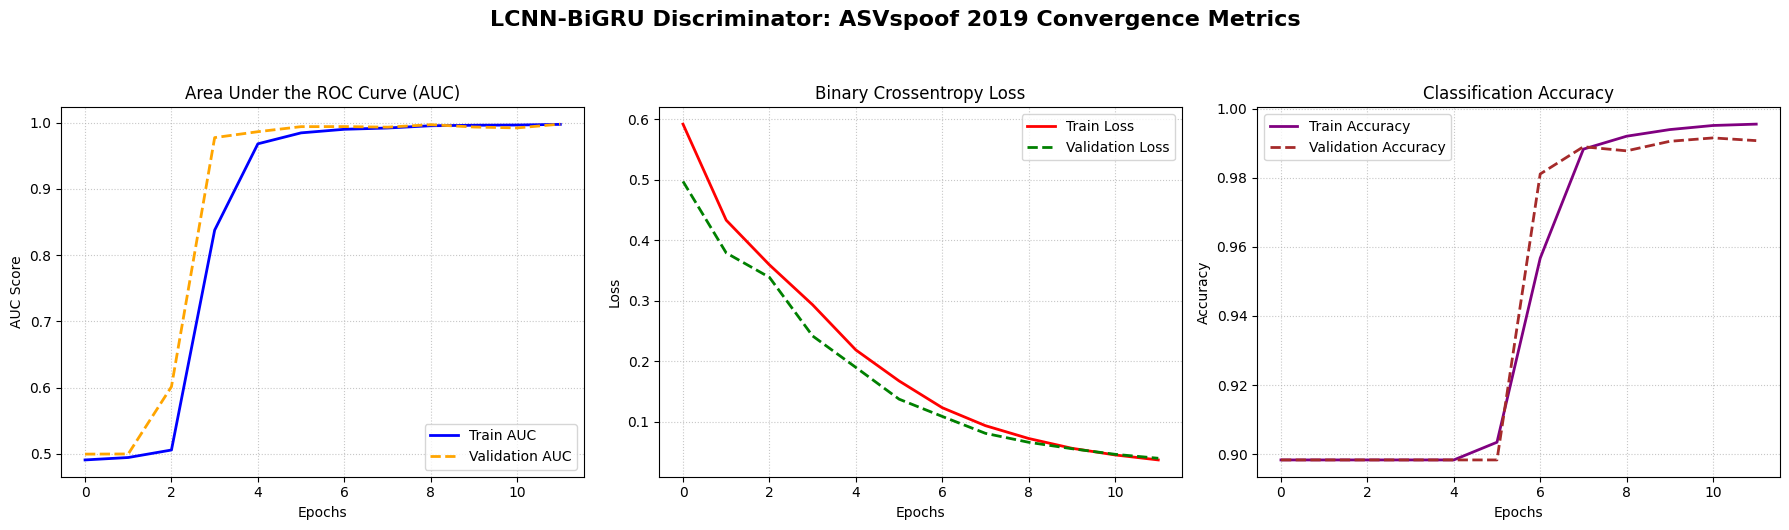

In [1]:
# 9. PLOT TRAINING HISTORY (FOR PROJECT REPORT)
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def generate_academic_plots(csv_path='MOdel2.0.csv'):
    if not Path(csv_path).exists():
        print(f"Error: {csv_path} not found. Ensure training has started.")
        return

    # Load metrics from disk
    df = pd.read_csv(csv_path)

    # Initialize a 1x3 academic plotting grid
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('LCNN-BiGRU Discriminator: ASVspoof 2019 Convergence Metrics', fontsize=16, fontweight='bold', y=1.05)

    # 1. AUC (The primary forensic metric)
    axes[0].plot(df['epoch'], df['auc'], label='Train AUC', color='blue', linewidth=2)
    axes[0].plot(df['epoch'], df['val_auc'], label='Validation AUC', color='orange', linewidth=2, linestyle='--')
    axes[0].set_title('Area Under the ROC Curve (AUC)')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('AUC Score')
    axes[0].grid(True, linestyle=':', alpha=0.7)
    axes[0].legend()

    # 2. Binary Crossentropy Loss
    axes[1].plot(df['epoch'], df['loss'], label='Train Loss', color='red', linewidth=2)
    axes[1].plot(df['epoch'], df['val_loss'], label='Validation Loss', color='green', linewidth=2, linestyle='--')
    axes[1].set_title('Binary Crossentropy Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, linestyle=':', alpha=0.7)
    axes[1].legend()

    # 3. Accuracy
    axes[2].plot(df['epoch'], df['accuracy'], label='Train Accuracy', color='purple', linewidth=2)
    axes[2].plot(df['epoch'], df['val_accuracy'], label='Validation Accuracy', color='brown', linewidth=2, linestyle='--')
    axes[2].set_title('Classification Accuracy')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('Accuracy')
    axes[2].grid(True, linestyle=':', alpha=0.7)
    axes[2].legend()

    plt.tight_layout()
    
    # Save a high-resolution 300 DPI PNG for the report
    save_file = 'MOdel2.0_training_graphs.png'
    plt.savefig(save_file, dpi=300, bbox_inches='tight')
    print(f"Academic plots successfully saved to {save_file}")
    
    plt.show()

# Generate the report graphs
generate_academic_plots()